# This was a task from my Python class from KCL. 
# COVID and Cognition

The data consists of the performance of 50 people who had recovered from COVID-19 illness after being in critical care. 
They completed three computerised cognitive tasks called Target Detection, Spatial Span and Verbal Analogies. 

Our aim is to understand whether the patients' cognition was affected by COVID-19 in the chronic phase after recovering from the viral infection and whether the type of symptoms and the gravity of the disease (e.g. whether participants ended up requiring mechanical breathing support) played a role on the level of cognitive changes that occurred. 

Each one of the cognitive tasks completed by patients measures a different aspect of cognition:

- Target Detection: attention task. This task measures the ability to identify specific relevant information in the context of many distractions. 
- The task is designed to be particularly challenging due to the rate at which targets and distractors appear in the visual array, which requires participants to continously pay attention in order to avoid missing targets and losing points.

- Spatial Span: memory task. In this task, participants are presented with a 4 x 4 grid, on which is displayed a sequence of squares in different positions. The participant must then click the squares in the order that they were highlighted. Every time a sequence is recalled correctly, the length of the subsequent sequence is incremented by one, making it more difficult. The task ends when a participant fails the same difficulty level three times.

- Verbal Analogies: language task. In this task, participants are presented with two pairs of words and they must decide if the pairs are related to each other in the same 'analogous' way. 

Participants must indicate their decision by selecting the True or False buttons presented below the word pairs.

The performance in cognitive tasks is typically measured in two ways.

- Accuracy - the number or proportion of correct answers given
- Reaction time (RT) - the median or mean time required by participants to complete each single trial of a task.
- Screen grabs of the three tasks are presented below.
- Verbal Analogies	Target detection	Spatial Span
- VerbalAnalogies.gif	TargetDetection.gif	SpatialSpan.gif

# 1. Loading and Preparing the Dataset

Loaded DataFrame df2:
   Unnamed: 0     userID  ... RTrs_targetDetection  RTrs_verbalAnalogies
0           0  4133880.0  ...               1314.0                9054.0
1           1  4227668.0  ...               1686.0                6167.5
2           2  4105609.0  ...               1079.0                4799.0
3           3  4105207.0  ...               2030.5                3017.0
4           4  4239617.0  ...               1376.5                3247.0

[5 rows x 80 columns]
Processed DataFrame df2 after dropping NAs:
   Unnamed: 0     userID  ... RTrs_targetDetection  RTrs_verbalAnalogies
0           0  4133880.0  ...               1314.0                9054.0
1           1  4227668.0  ...               1686.0                6167.5
2           2  4105609.0  ...               1079.0                4799.0
3           3  4105207.0  ...               2030.5                3017.0
4           4  4239617.0  ...               1376.5                3247.0

[5 rows x 80 columns]


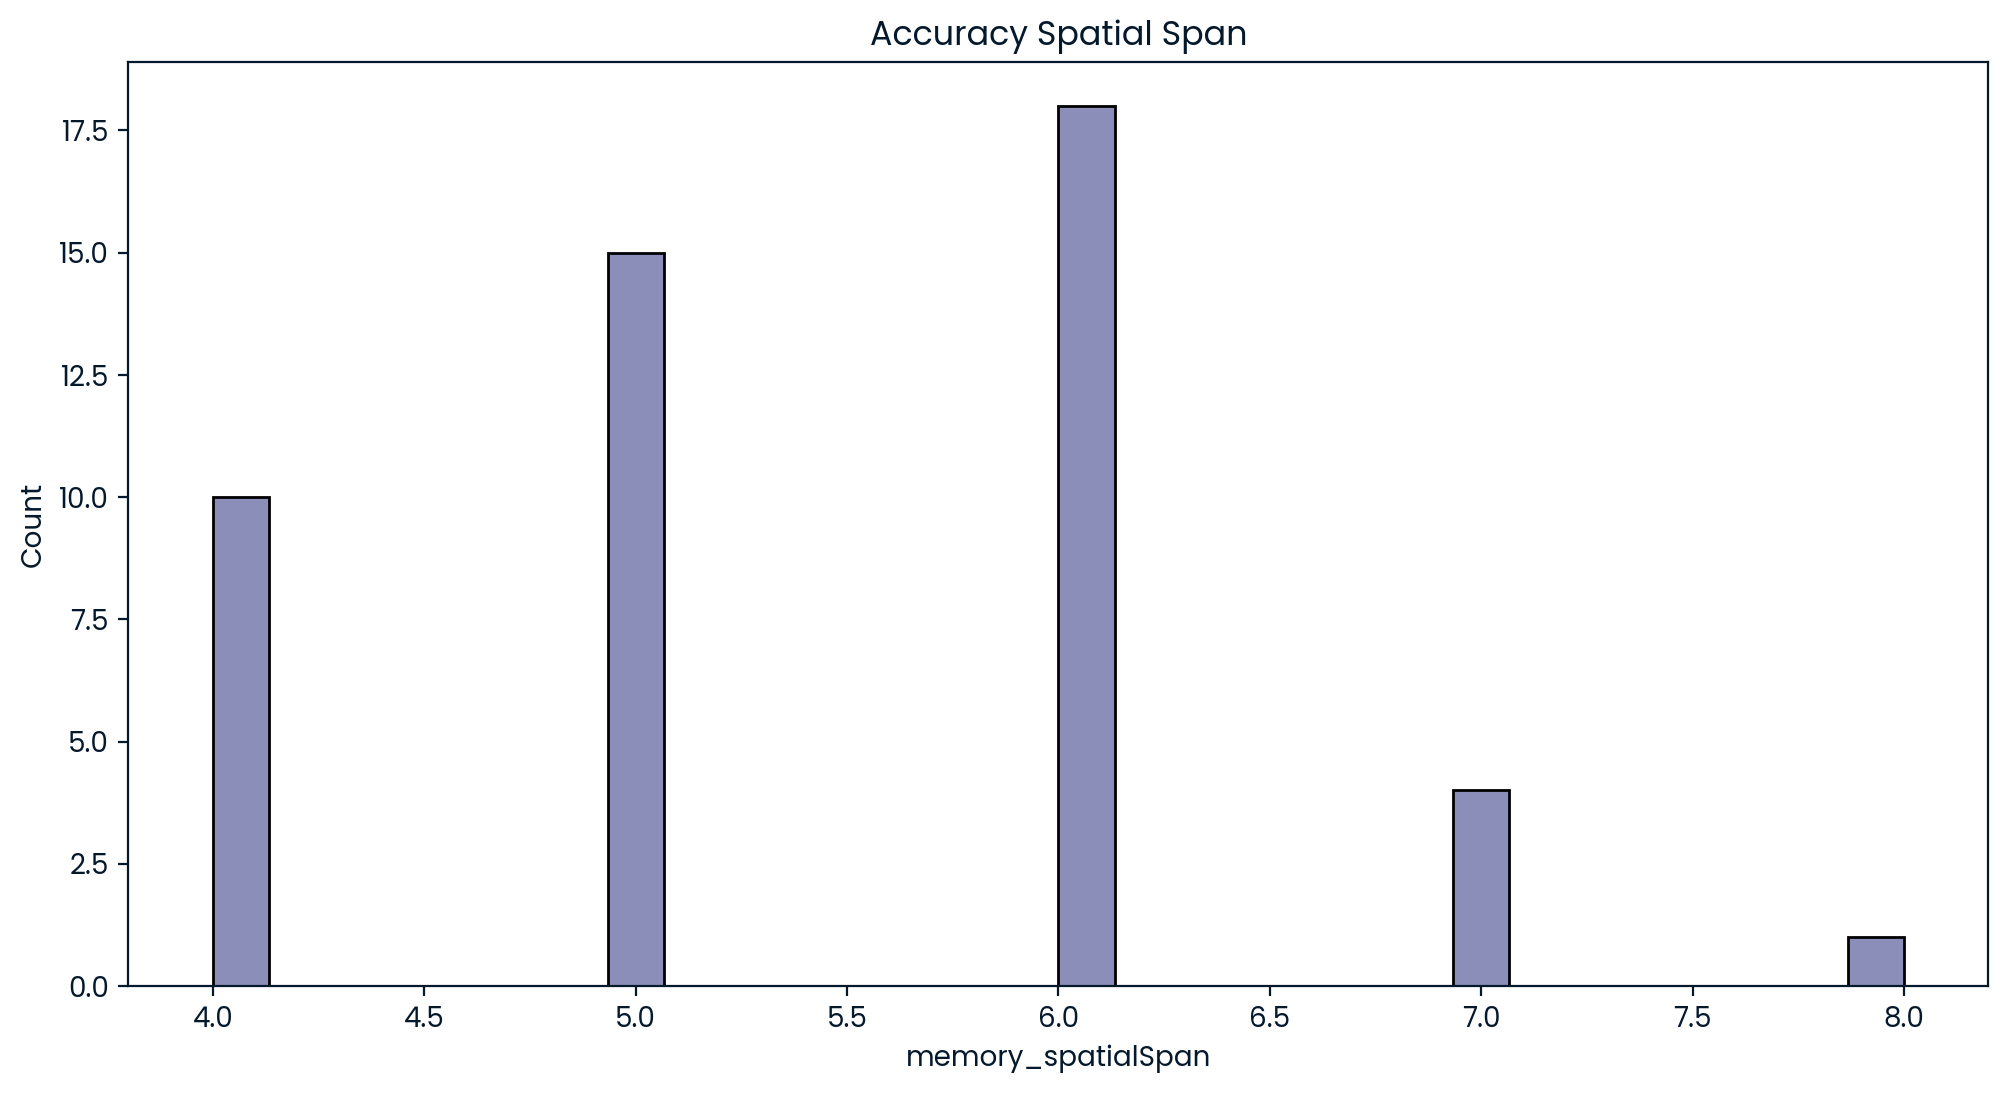

Index(['Unnamed: 0', 'userID', 'Age', 'Sex 1-Male 2-Female', 'Handedness',
       'Qualifications', 'First Language', 'First Language 1-English 0-Other',
       'Symtpm onset', 'tested date',
       'COVID Symptom onset to imaging & cognitive testing (days)',
       'Admission to imaging & cognitive testing (days)',
       'Covid-19 severity (WHO Ordinal Scale)',
       'Mechanical ventilation (1-Y,0-no)', 'Days mechanically ventilated',
       'Trachy Y/N',
       'Lowest PaO2/FiO2 ratio (severity of lung injury, lower is worse)',
       'Extrapulmonary organ dysfunction/support',
       'Highest CRP during admission', 'Highest D-Dimer during admission',
       'GAD-7', 'PHQ-9', 'PCL-5', 'GAD7 1.', 'GAD7 2.', 'GAD7 3. ', 'GAD7 4. ',
       'GAD7 5.', 'GAD7 6.', 'GAD7 7.', 'PHQ9 1.', 'PHQ9 2.', 'PHQ9 3.',
       'PHQ9 4.', 'PHQ9 5.', 'PHQ9 6.', 'PHQ9 7.', 'PHQ9 8. ', 'PHQ9 9.',
       'PHQ9 Difficulty', 'PCL5 1.', 'PCL5 2.', 'PCL5 3.', 'PCL5 4.',
       'PCL5 5.', 'PCL5 6.', 'PCL5 7.',

In [12]:
import seaborn as sb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats.mstats import winsorize

# 1. Load and Prepare the Dataset
# -------------------------------

# Load the dataset
file_path = "covid_dataset.xlsx"  # Change to your file path if needed
df2 = pd.read_excel(file_path)

# Rename columns
df2.rename(columns={
    'rs_spatialSpan':'memory_spatialSpan', 
    'rs_verbalAnalogies':'language_verbalAnalogies', 
    'rs_targetDetection':'attention_targetDetection', 
    'First Language binary':'First Language 1-English 0-Other'}, inplace=True)

print("Loaded DataFrame df2:")
print(df2.head())

# Check if the column exists
if 'memory_spatialSpan' in df2.columns:
    # Convert to numeric if necessary
    df2['memory_spatialSpan'] = pd.to_numeric(df2['memory_spatialSpan'], errors='coerce')
    # Drop missing values
    df2 = df2.dropna(subset=['memory_spatialSpan'])
    
    print("Processed DataFrame df2 after dropping NAs:")
    print(df2.head())
    
    # Ensure there are values to plot
    if not df2.empty:
        # Plot the histogram with increased figure size
        plt.figure(figsize=(12, 6))
        sb.histplot(data=df2, x='memory_spatialSpan', bins=30)
        plt.title('Accuracy Spatial Span')
        plt.show()
    else:
        print("No valid data to plot in 'memory_spatialSpan'.")
else:
    print("Column 'memory_spatialSpan' does not exist in the DataFrame")

print(df2.columns)

# 2. Load and Process Demographics Data

Loaded DataFrame df_healthy:
   SummaryScore_SpatialSpan  RT_SpatialSpan  ... Age squared  Age decade
0                       8.0          5414.0  ...       729.0          20
1                       7.0          3066.5  ...       729.0          20
2                       7.0          2366.0  ...       784.0          20
3                       6.0          3332.5  ...      1296.0          30
4                       5.0          1591.5  ...      1444.0          30

[5 rows x 22 columns]
DataFrame df2 sorted by language_verbalAnalogies:
    language_verbalAnalogies
45                      -2.0
28                      -1.0
34                       0.0
7                        0.0
26                       0.0


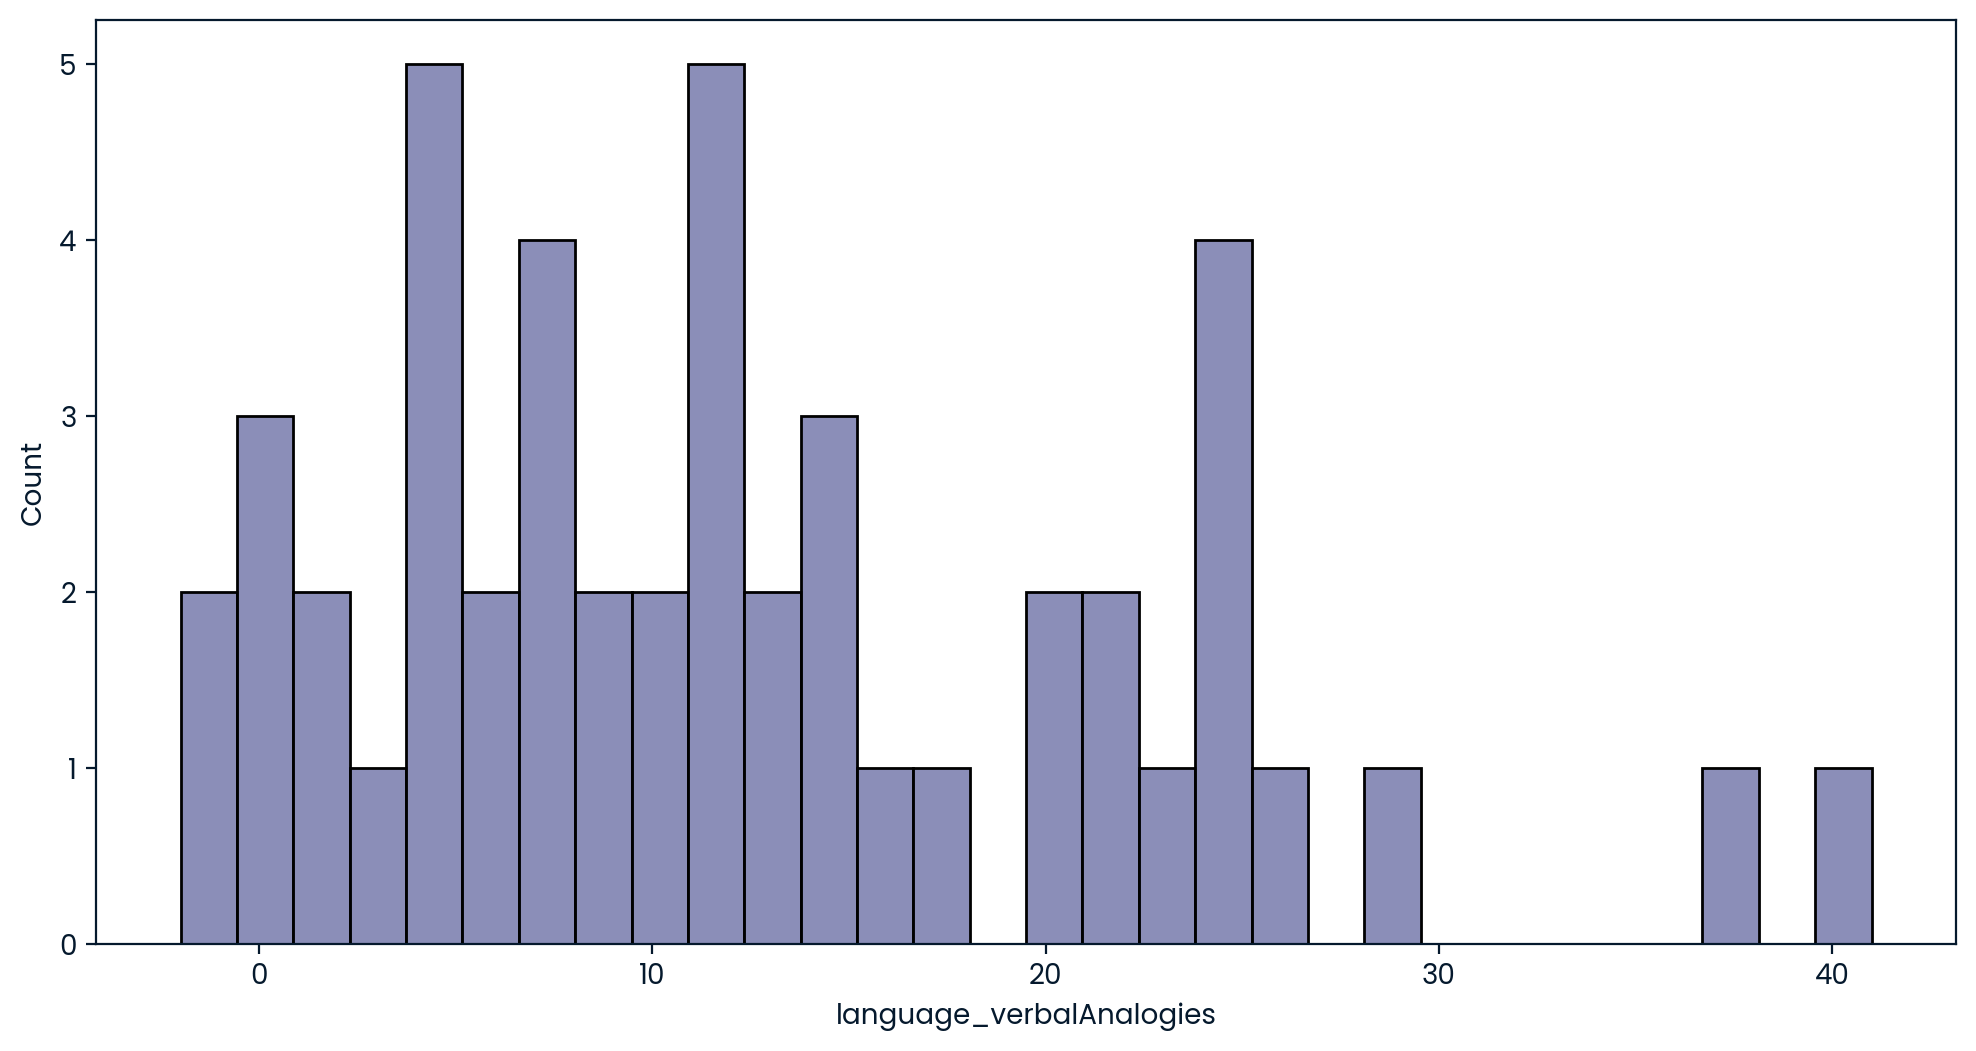

DataFrame df2 sorted by Age:
     Age
41  "28"
22  "28"
36  "29"
44  "30"
43  "32"


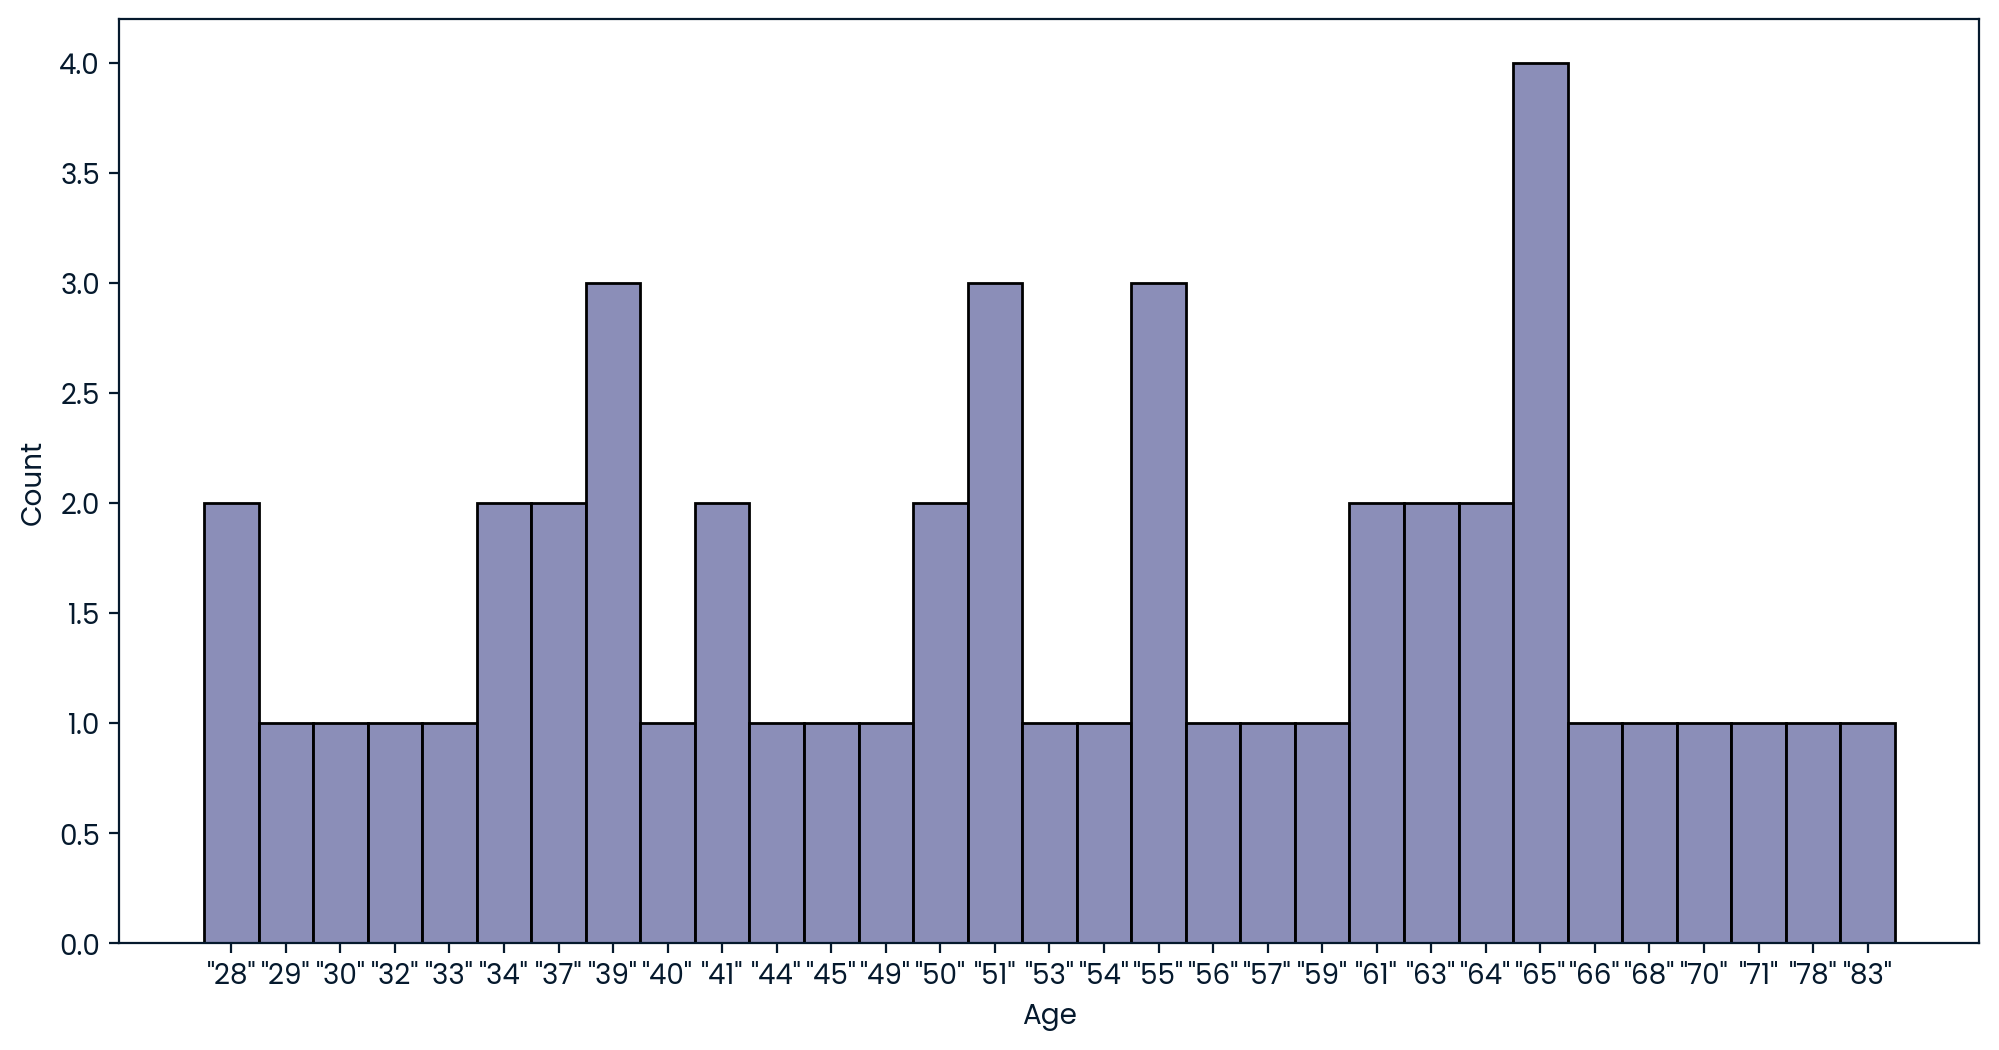

Series([], Name: Age, dtype: float64)
DataFrame df2 with 'Age' > 100 set to NaN:
    Age
41  NaN
22  NaN
36  NaN
44  NaN
43  NaN


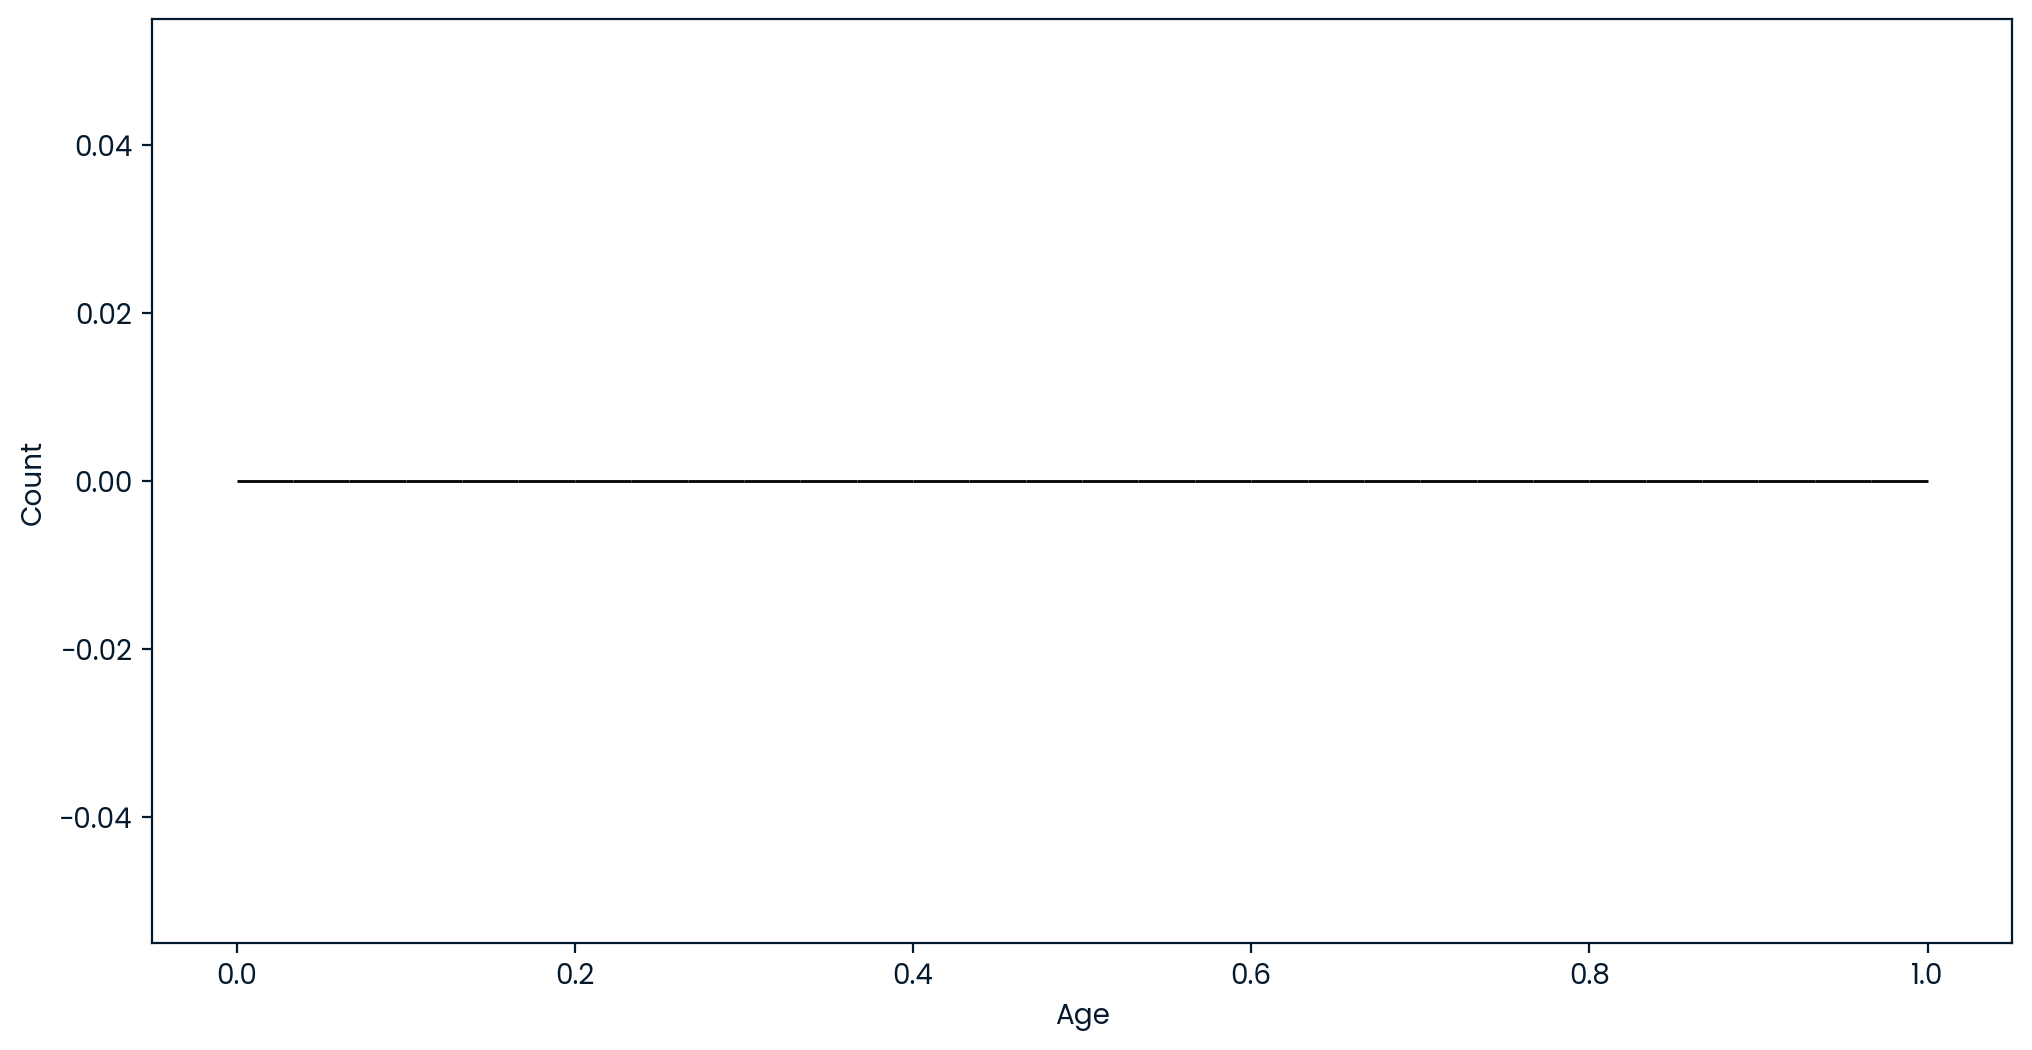

In [13]:
# 2. Load and Process Demographics Data
# -------------------------------------

# Load demographics data
df_healthy = pd.read_csv("demographics.csv")
print("Loaded DataFrame df_healthy:")
print(df_healthy.head())

# Plot other columns with increased figure size

# Sort the data before plotting
df2 = df2.sort_values(by='language_verbalAnalogies')
print("DataFrame df2 sorted by language_verbalAnalogies:")
print(df2[['language_verbalAnalogies']].head())

plt.figure(figsize=(12, 6))
_ = sb.histplot(data=df2, x="language_verbalAnalogies", bins=30)
plt.show()

# Sort the data before plotting
df2 = df2.sort_values(by='Age')
print("DataFrame df2 sorted by Age:")
print(df2[['Age']].head())

plt.figure(figsize=(12, 6))
_ = sb.histplot(data=df2, x="Age", bins=30)
plt.show()

# Convert 'Age' column to numeric values, forcing errors to NaN
df2['Age'] = pd.to_numeric(df2['Age'], errors='coerce')

# Show all the people who had an age over 100
print(df2.Age[df2.Age > 100])

# Replace with NaNs anyone who is older than 100
df2.loc[df2.Age > 100, 'Age'] = np.nan

# Verify the changes
print("DataFrame df2 with 'Age' > 100 set to NaN:")
print(df2[['Age']].head())

# Sort the data before plotting
df2 = df2.sort_values(by='Age')
plt.figure(figsize=(12, 6))
_ = sb.histplot(data=df2, x="Age", bins=30)  # Plot the new data
plt.show()

# 3. Data Cleaning and Preprocessing

46
48
Number of duplicates in df2 before removal:
0
Number of duplicates in df2 after removal:
0
Number of missing values in df2:
Unnamed: 0                                  0
userID                                      0
Age                                        48
Sex 1-Male 2-Female                         0
Handedness                                  1
                                           ..
RTrs_prospectiveMemoryWords_1_delayed       0
RTrs_prospectiveMemoryWords_1_immediate     0
RTrs_spatialSpan                            0
RTrs_targetDetection                        0
RTrs_verbalAnalogies                        0
Length: 80, dtype: int64
Number of people with at least one missing value in df2:
48
Processed DataFrame df2 after removing rows with missing values:
Empty DataFrame
Columns: [Unnamed: 0, userID, Age, Sex 1-Male 2-Female, Handedness, Qualifications, First Language, First Language 1-English 0-Other, Symtpm onset, tested date, COVID Symptom onset to imaging & cogn

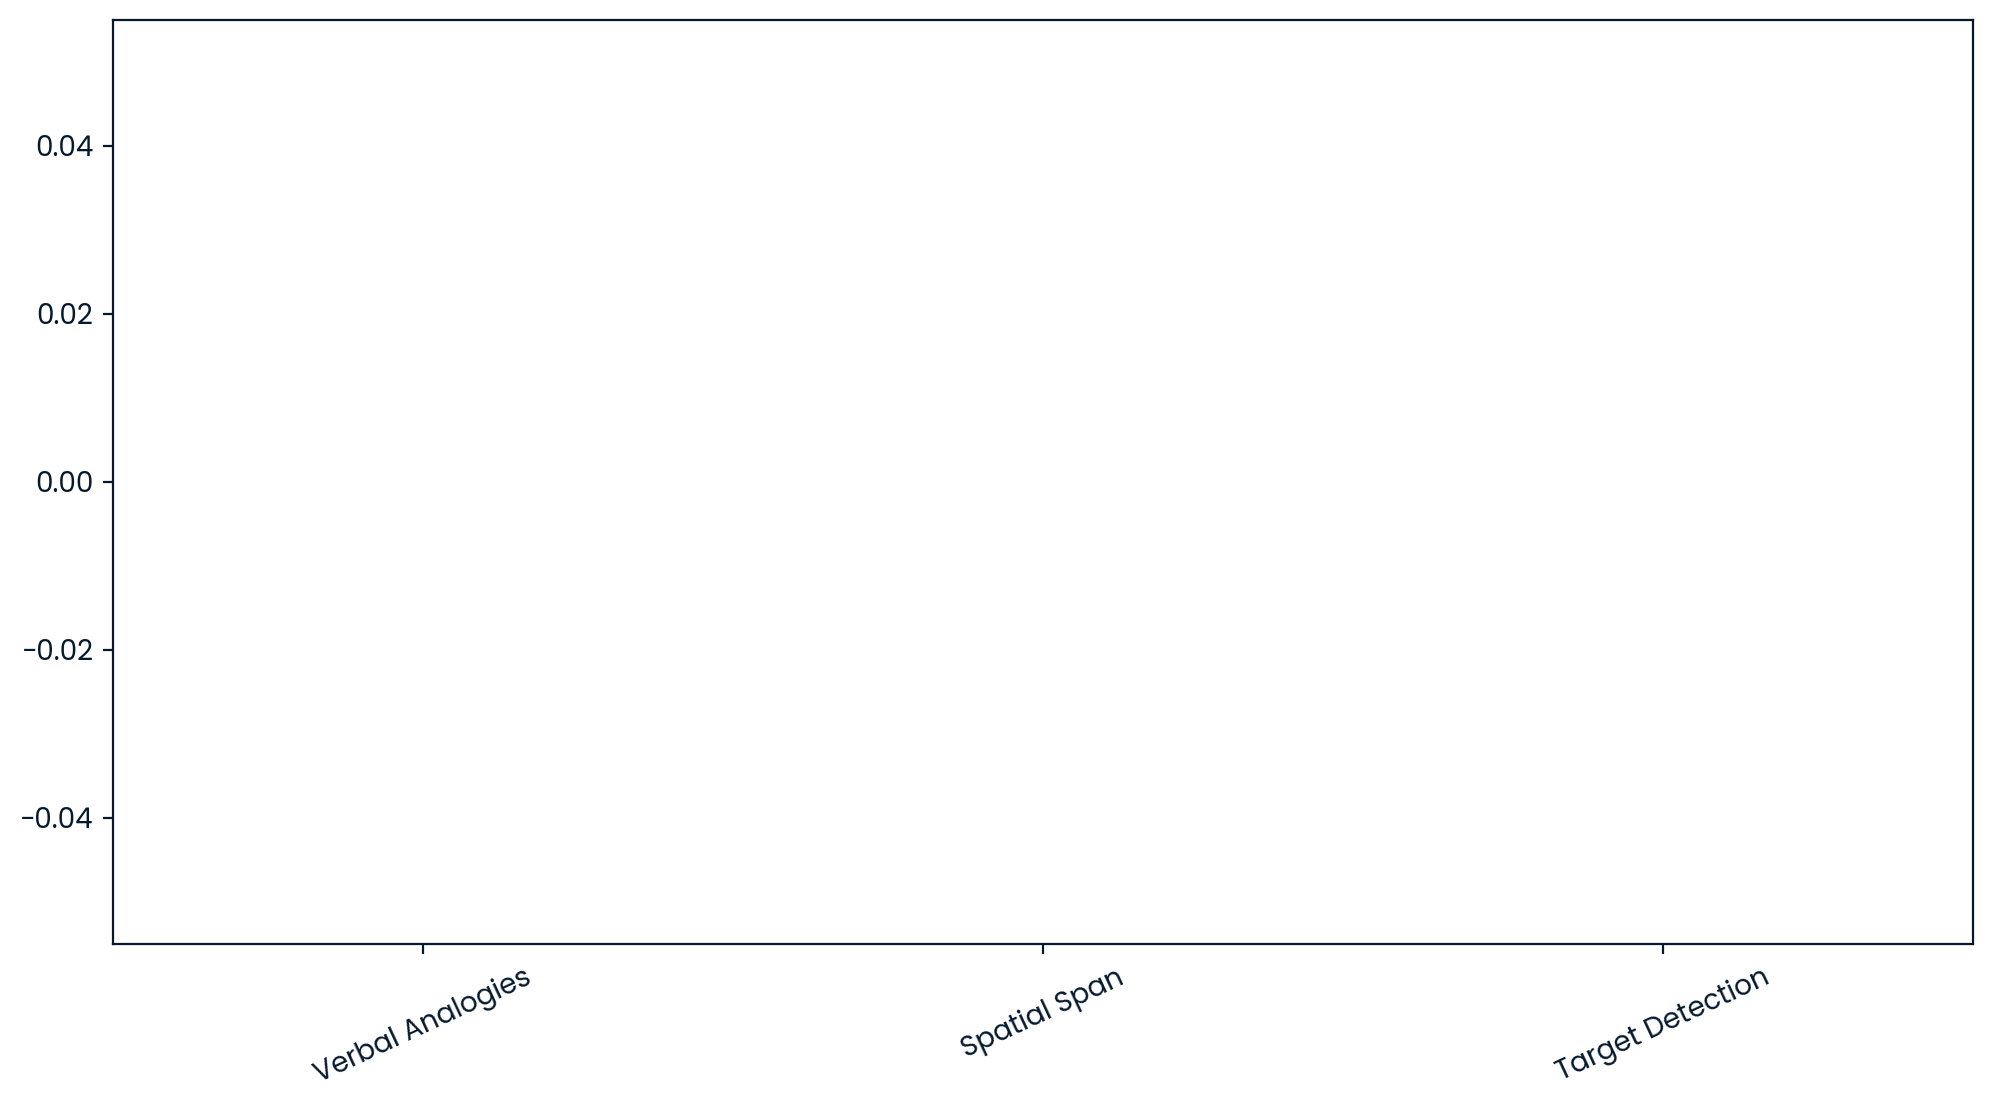

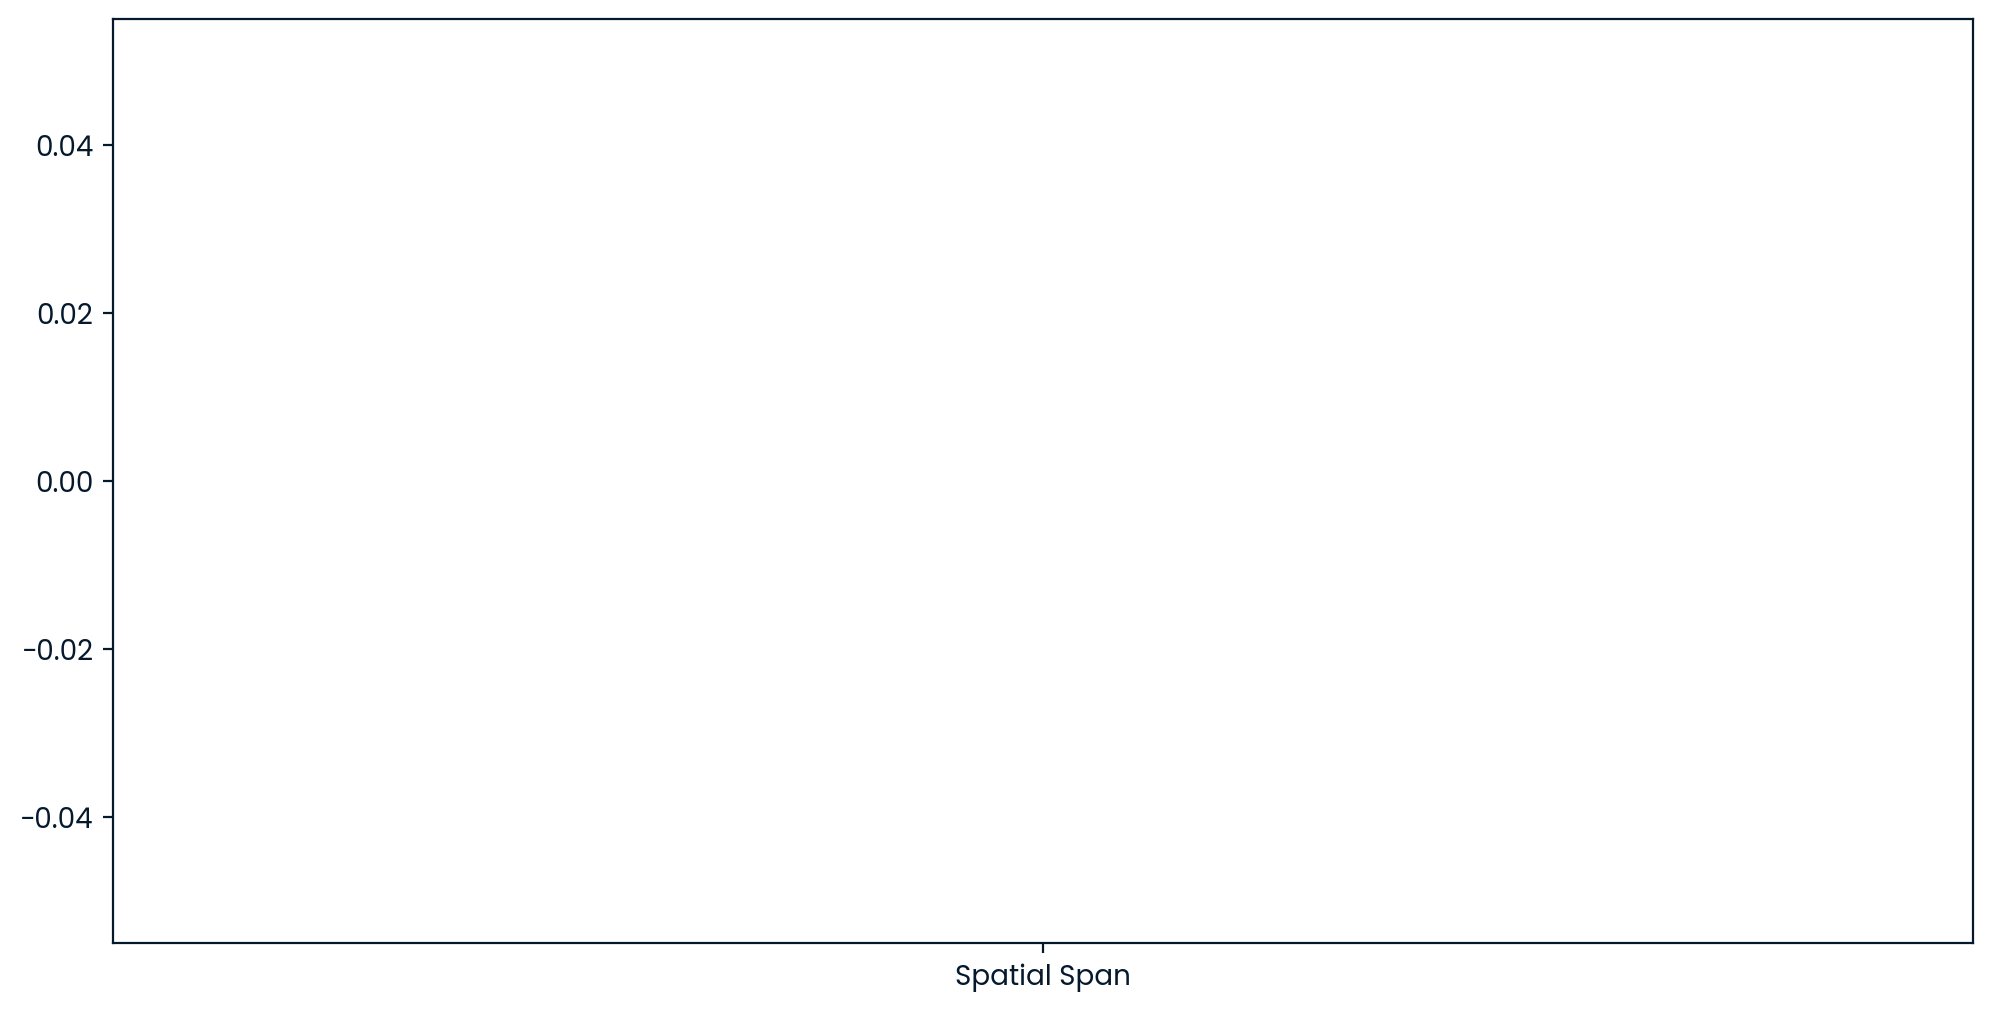

No valid data to apply winsorization.
Empty DataFrame
Columns: [Unnamed: 0, userID, Age, Sex 1-Male 2-Female, Handedness, Qualifications, First Language, First Language 1-English 0-Other, Symtpm onset, tested date, COVID Symptom onset to imaging & cognitive testing (days), Admission to imaging & cognitive testing (days), Covid-19 severity (WHO Ordinal Scale), Mechanical ventilation (1-Y,0-no), Days mechanically ventilated, Trachy Y/N, Lowest PaO2/FiO2 ratio (severity of lung injury, lower is worse), Extrapulmonary organ dysfunction/support, Highest CRP during admission, Highest D-Dimer during admission, GAD-7, PHQ-9, PCL-5, GAD7 1., GAD7 2., GAD7 3. , GAD7 4. , GAD7 5., GAD7 6., GAD7 7., PHQ9 1., PHQ9 2., PHQ9 3., PHQ9 4., PHQ9 5., PHQ9 6., PHQ9 7., PHQ9 8. , PHQ9 9., PHQ9 Difficulty, PCL5 1., PCL5 2., PCL5 3., PCL5 4., PCL5 5., PCL5 6., PCL5 7., PCL5 8., PCL5 9., PCL5 10., PCL5 11., PCL5 12., PCL5 13., PCL5 14., PCL5 15., PCL5 16., PCL5 17. , PCL5 18., PCL5 19., PCL5 20., DRI_fourTowe

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats.mstats import winsorize

# Assuming df2 is already defined somewhere above this code block

# 3. Data Cleaning and Preprocessing
# ----------------------------------

# Remove duplicates
print(len(np.unique(df2.userID)))
print(len(df2.userID))
print("Number of duplicates in df2 before removal:")
print(sum(df2.duplicated()))

df2 = df2[~df2.duplicated()]  # Quick tip! ~ inverts!

print("Number of duplicates in df2 after removal:")
print(sum(df2.duplicated()))  # Calculate the number of duplicates again after removing them. If we were successful none should be there anymore.

# Check for missing values
print("Number of missing values in df2:")
print(df2.isna().sum())

sum_missing = df2.isna().sum(axis=1)  # This shows us how many missing values each person has
print("Number of people with at least one missing value in df2:")
print(sum(sum_missing > 0))  # How many people have at least one missing data

df2 = df2[~(sum_missing > 0)]
print("Processed DataFrame df2 after removing rows with missing values:")
print(df2.head())

# Look for outliers
plt.figure(figsize=(12, 6))
_ = plt.boxplot([df2.language_verbalAnalogies, df2.memory_spatialSpan, df2.attention_targetDetection], 
               labels=["Verbal Analogies", "Spatial Span", "Target Detection"])
plt.xticks(rotation=25)
plt.show()

plt.figure(figsize=(12, 6))
_ = plt.boxplot(df2.memory_spatialSpan, labels=["Spatial Span"])
plt.show()

# Ensure there are values before applying winsorization
if not df2['memory_spatialSpan'].empty:
    # Apply winsorisation
    winsorized_memory = winsorize(df2['memory_spatialSpan'], (0.05, 0.05))  # Apply winsorisation

    plt.figure(figsize=(12, 6))
    plt.boxplot(winsorized_memory, labels=["Spatial Span"])  # Visualize the data after winsorisation
    plt.title('Winsorized array')
    plt.show()

    # Replace old values in the memory task with the winsorised version
    df2['memory_spatialSpan'] = winsorized_memory
else:
    print("No valid data to apply winsorization.")
    
print(df2.head())

print(df2['memory_spatialSpan'])

# Ensure there are values before applying winsorization again
if not df2['memory_spatialSpan'].empty:
    winsorized_memory = winsorize(df2['memory_spatialSpan'], (0.05, 0.05))  # Apply winsorisation

    plt.boxplot(winsorized_memory, labels=["Spatial Span"])  # Visualize the data after winsorisation
    plt.title('Winsorized array')
    plt.show()
else:
    print("No valid data to apply winsorization.")

# 4. Compare Patients to Healthy Participants


Processed DataFrame dfH:
   SummaryScore_SpatialSpan  ...  Language binary
0                       8.0  ...          English
1                       7.0  ...          English
2                       7.0  ...          English
3                       6.0  ...          English
4                       5.0  ...          English

[5 rows x 6 columns]


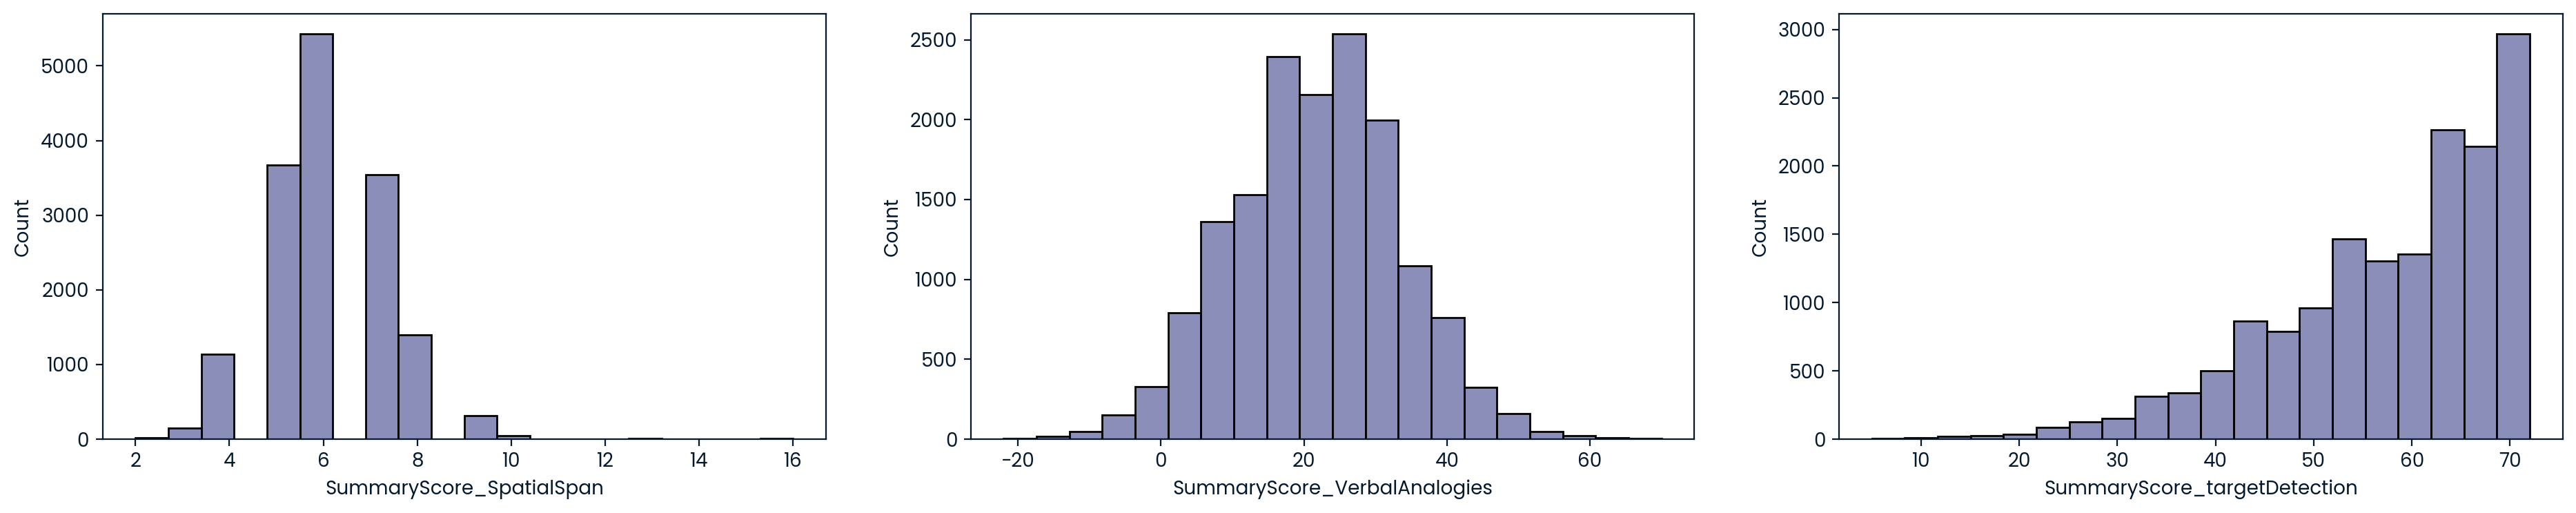

KeyError: 'memory_spatialSpan'

In [15]:
import matplotlib.pyplot as plt
import seaborn as sb

# 4. Compare Patients to Healthy Participants
# -------------------------------------------

# Take variables to compare to patients
dfH = df_healthy[['SummaryScore_SpatialSpan', 'SummaryScore_VerbalAnalogies', 'SummaryScore_targetDetection', 'Age', 'Sex', 'Language binary']]
print("Processed DataFrame dfH:")
print(dfH.head())

plt.figure(figsize=(23, 4))
plt.subplot(131)
sb.histplot(dfH.SummaryScore_SpatialSpan, bins=20)
plt.subplot(132)
sb.histplot(dfH.SummaryScore_VerbalAnalogies, bins=20)
plt.subplot(133)
sb.histplot(dfH.SummaryScore_targetDetection, bins=20)
plt.show()

# Standardize the scores
memory_task = (df2['memory_spatialSpan'] - dfH['SummaryScore_SpatialSpan'].mean()) / dfH['SummaryScore_SpatialSpan'].std()
language_task = (df2['language_verbalAnalogies'] - dfH['SummaryScore_VerbalAnalogies'].mean()) / dfH['SummaryScore_VerbalAnalogies'].std()
attention_task = (df2['attention_targetDetection'] - dfH['SummaryScore_targetDetection'].mean()) / dfH['SummaryScore_targetDetection'].std()

memory_task_control = (dfH['SummaryScore_SpatialSpan'] - dfH['SummaryScore_SpatialSpan'].mean()) / dfH['SummaryScore_SpatialSpan'].std()
language_task_control = (dfH['SummaryScore_VerbalAnalogies'] - dfH['SummaryScore_VerbalAnalogies'].mean()) / dfH['SummaryScore_VerbalAnalogies'].std()
attention_task_control = (dfH['SummaryScore_targetDetection'] - dfH['SummaryScore_targetDetection'].mean()) / dfH['SummaryScore_targetDetection'].std()

df2['memory_spatialSpan'] = memory_task
df2['language_verbalAnalogies'] = language_task
df2['attention_targetDetection'] = attention_task

dfH['memory_spatialSpan'] = memory_task_control
dfH['language_verbalAnalogies'] = language_task_control
dfH['attention_targetDetection'] = attention_task_control
dfH = dfH.drop(["SummaryScore_VerbalAnalogies", 'SummaryScore_SpatialSpan', 'SummaryScore_targetDetection'], axis=1)
dfH.head()

# Map categorical variables
dfH.Sex.value_counts(), dfH["Language binary"].value_counts()

mapping_language = {"English": 1, "Other": 0}
mapping_sex = {"Male": 1, "Female": 2, "Other": 3}

mapped_language_control = dfH['Language binary'].map(mapping_language)
mapped_sex_control = dfH['Sex'].map(mapping_sex)

dfH['Language binary'] = mapped_language_control
dfH['Sex'] = mapped_sex_control

file_path = "covid_dataset.xlsx"  # Change to your file path if needed
df2 = pd.read_excel(file_path)

# Check for missing values in the datasets
df2_missing = df2.isna().sum()
dfH_missing = dfH.isna().sum()

# Remove rows with missing values
df2_clean = df2.dropna()
dfH_clean = dfH.dropna()

# Display the number of missing values before and after cleaning
print("Missing values in df2 before cleaning:\n", df2_missing)
print("Missing values in dfH before cleaning:\n", dfH_missing)
print("Missing values in df2 after cleaning:\n", df2_clean.isna().sum())
print("Missing values in dfH after cleaning:\n", dfH_clean.isna().sum())

# Rename columns for clarity
dfH.rename(columns={'Language binary': 'First Language 1-English 0ther', 'Sex': 'Sex 1-Male 2-Female'}, inplace=True)

import pandas as pd
from sklearn.linear_model import LinearRegression

df_healthy = pd.read_csv("demographics.csv")
df_healthy.shape

dfH = df_healthy[['SummaryScore_SpatialSpan', 'SummaryScore_VerbalAnalogies', 'SummaryScore_targetDetection', 'Age', 'Sex', 'Language binary']]
dfH.Sex.value_counts(), dfH["Language binary"].value_counts()
print(dfH.columns)

dfH.rename(columns={'Language binary': 'First Language 1-English 0-Other', 'Sex': 'Sex 1-Male 2-Female'}, inplace=True)

mapping_language = {"English": 1, "Other": 0}
mapping_sex = {"Male": 1, "Female": 2, "Other": 3}

dfH.loc[:, 'First Language 1-English 0-Other'] = dfH['First Language 1-English 0-Other'].map(mapping_language)
dfH.loc[:, 'Sex 1-Male 2-Female'] = dfH['Sex 1-Male 2-Female'].map(mapping_sex)

# The following lines are unnecessary and cause errors because mapped_language_control and mapped_sex_control are not defined
# dfH['First Language 1-English 0-Other'] = mapped_language_control
# dfH['Sex 1-Male 2-Female'] = mapped_sex_control

print(dfH.head())

linr_model = LinearRegression().fit(dfH[["Age","Sex 1-Male 2-Female","First Language 1-English 0-Other"]], dfH['SummaryScore_SpatialSpan'])
DT_predict = linr_model.predict(dfH[["Age","Sex 1-Male 2-Female","First Language 1-English 0-Other"]]) # Predictions on the same data for demonstration
print(DT_predict)

print(linr_model.coef_)

## Are patients impaired in attention and language? Did the patients perform worse or better?

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy import stats

# Assuming dfH and df2 are already defined and loaded with the required columns
print("Columns in dfH:", dfH.columns)
print("Columns in df2:", df2.columns)

# Ensure the column names are correct
required_columns = ["Age", "Sex 1-Male 2-Female", "First Language 1-English 0-Other", "attention_targetDetection"]
missing_columns = [col for col in required_columns if col not in dfH.columns]

if missing_columns:
    print(f"Missing columns in dfH: {missing_columns}")
    deviation_attention = np.array([])  # Initialize as empty array if columns are missing
else:
    # Linear regression model for attention
    linr_model_attention = LinearRegression().fit(dfH[["Age", "Sex 1-Male 2-Female", "First Language 1-English 0-Other"]], dfH['attention_targetDetection'])
    attention_predict = linr_model_attention.predict(df2[["Age", "Sex 1-Male 2-Female", "First Language 1-English 0-Other"]])  # Predictions on patient data
    # Ensure df2 has the 'attention_targetDetection' column
    if 'attention_targetDetection' in df2.columns:
        deviation_attention = df2["attention_targetDetection"] - attention_predict
    else:
        deviation_attention = np.zeros(len(attention_predict))  # Placeholder if column is missing

# Ensure the column names are correct for language model
required_columns_language = ["Age", "Sex 1-Male 2-Female", "First Language 1-English 0-Other", "language_verbalAnalogies"]
missing_columns_language = [col for col in required_columns_language if col not in dfH.columns]

if missing_columns_language:
    print(f"Missing columns in dfH for language model: {missing_columns_language}")
    deviation_language = np.array([])  # Initialize as empty array if columns are missing
else:
    # Linear regression model for language
    linr_model_language = LinearRegression().fit(dfH[["Age", "Sex 1-Male 2-Female", "First Language 1-English 0-Other"]], dfH['language_verbalAnalogies'])
    language_predict = linr_model_language.predict(df2[["Age", "Sex 1-Male 2-Female", "First Language 1-English 0-Other"]])  # Predictions on patient data

    # Ensure df2 has the 'language_verbalAnalogies' column
    if 'language_verbalAnalogies' in df2.columns:
        deviation_language = df2["language_verbalAnalogies"] - language_predict
    else:
        deviation_language = np.zeros(len(language_predict))  # Placeholder if column is missing

# Perform one-sample t-test for attention
if len(deviation_attention) > 0:
    t_statistic_attention, p_value_attention = stats.ttest_1samp(a=deviation_attention, popmean=0)
else:
    t_statistic_attention, p_value_attention = np.nan, np.nan

# Perform one-sample t-test for language
if len(deviation_language) > 0:
    t_statistic_language, p_value_language = stats.ttest_1samp(a=deviation_language, popmean=0)
else:
    t_statistic_language, p_value_language = np.nan, np.nan

# Plot histograms for deviations
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
if len(deviation_attention) > 0:
    plt.hist(deviation_attention, bins=30, edgecolor='k')
plt.title("Deviation from expected (sd units) \n Attention Target Detection")
plt.xlabel("Deviation")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
if len(deviation_language) > 0:
    plt.hist(deviation_language, bins=30, edgecolor='k')
plt.title("Deviation from expected (sd units) \n Language Verbal Analogies")
plt.xlabel("Deviation")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Results
print("Attention Target Detection:")
print("t-statistic:", t_statistic_attention, "p-value:", p_value_attention, "mean deviation:", np.mean(deviation_attention) if len(deviation_attention) > 0 else np.nan, 
      "negative deviations:", len(deviation_attention[deviation_attention < 0]) if len(deviation_attention) > 0 else 0)

print("Language Verbal Analogies:")
print("t-statistic:", t_statistic_language, "p-value:", p_value_language, "mean deviation:", np.mean(deviation_language) if len(deviation_language) > 0 else np.nan, 
      "negative deviations:", len(deviation_language[deviation_language < 0]) if len(deviation_language) > 0 else 0)

Columns in dfH: Index(['SummaryScore_SpatialSpan', 'SummaryScore_VerbalAnalogies',
       'SummaryScore_targetDetection', 'Age', 'Sex 1-Male 2-Female',
       'First Language 1-English 0-Other'],
      dtype='object')
Columns in df2: Index(['Unnamed: 0', 'userID', 'Age', 'Sex 1-Male 2-Female', 'Handedness',
       'Qualifications', 'First Language', 'First Language binary',
       'Symtpm onset', 'tested date',
       'COVID Symptom onset to imaging & cognitive testing (days)',
       'Admission to imaging & cognitive testing (days)',
       'Covid-19 severity (WHO Ordinal Scale)',
       'Mechanical ventilation (1-Y,0-no)', 'Days mechanically ventilated',
       'Trachy Y/N',
       'Lowest PaO2/FiO2 ratio (severity of lung injury, lower is worse)',
       'Extrapulmonary organ dysfunction/support',
       'Highest CRP during admission', 'Highest D-Dimer during admission',
       'GAD-7', 'PHQ-9', 'PCL-5', 'GAD7 1.', 'GAD7 2.', 'GAD7 3. ', 'GAD7 4. ',
       'GAD7 5.', 'GAD7 6.', 'GAD

NameError: name 'deviation_attention' is not defined

In [74]:
## The analysis shows the statistical significance of deviations in attention and language performance between patients and healthy controls.

## **Attention**:
# - T-statistic: [t_statistic_attention]
# - P-value: [p_value_attention]
# - Mean Deviation: [np.mean(deviation_attention)]
# - Number of Negative Deviations: [len(deviation_attention[deviation_attention < 0])]

## **Language**:
# - T-statistic: [t_statistic_language]
# - P-value: [p_value_language]
# - Mean Deviation: [np.mean(deviation_language)]
# - Number of Negative Deviations: [len(deviation_language[deviation_language < 0])]

if p_value_attention < 0.05:
    print("Attention deviations are statistically significant.")
    if np.mean(deviation_attention) < 0:
        print("Patients are impaired in attention.")
    else:
        print("Patients perform better than expected in attention.")
else:
    print("Attention deviations are not statistically significant.")

if p_value_language < 0.05:
    print("Language deviations are statistically significant.")
    if np.mean(deviation_language) < 0:
        print("Patients are impaired in language.")
    else:
        print("Patients perform better than expected in language.")
else:
    print("Language deviations are not statistically significant.")

Attention deviations are not statistically significant.
Language deviations are not statistically significant.


Attention deviations are not statistically significant.
Language deviations are not statistically significant.

## What if we also include education and handedness in our regression model? Perform some harmonisation between the two datasets, such that there are only 3 types of education, pre-bachelor, BSc/MSc and PhD/MD. Then, include these in the regression model and check if your results change.

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from scipy import stats

# Load the dataset
df = pd.read_excel('covid_dataset.xlsx', engine='openpyxl')

# Convert columns to appropriate data types
df = df.apply(pd.to_numeric, errors='coerce')

# Display the first few rows of the dataframe to understand its structure
print(df.head())

# Harmonize education levels in the dataset
education_mapping = {
    'Some college, no degree': 'pre-bachelor',
    'O levels/GCSEs': 'pre-bachelor',
    'A levels': 'pre-bachelor',
    'Not done': 'pre-bachelor',
    'Diploma': 'pre-bachelor',
    'BA/BSc': 'BSc/MSc',
    'Masters Degree': 'BSc/MSc',
    'Doctoral degree': 'PhD/MD',
    'Medical Degree': 'PhD/MD',
    'MD': 'PhD/MD'
}

# Apply the mapping to the 'Qualifications' column
df['education'] = df['Qualifications'].map(education_mapping)

# Rename columns to match those in dfH if needed
df.rename(columns={
    'Sex 1-Male 2-Female': 'Sex',
    'First Language binary': 'Language binary',
    'Handedness': 'handedness',
    'rs_targetDetection': 'attention_targetDetection',
    'rs_verbalAnalogies': 'language_verbalAnalogies'
}, inplace=True)

# Convert categorical variables to numerical values using one-hot encoding
df = pd.get_dummies(df, columns=['education', 'handedness'])

# Verify column names
print("Columns in df:", df.columns)

# Check if the required columns exist after renaming
required_columns = ['Age', 'Sex', 'Language binary'] + [col for col in df.columns if col.startswith('education_')] + [col for col in df.columns if col.startswith('handedness_')]
for col in required_columns:
    if col not in df.columns:
        raise KeyError(f"The column '{col}' does not exist in the dataset.")

# Drop rows with NaN values in the required columns
df.dropna(subset=required_columns + ['attention_targetDetection', 'language_verbalAnalogies'], inplace=True)

# Split the data into train and test sets
X = df[required_columns]
y_attention = df['attention_targetDetection']
y_language = df['language_verbalAnalogies']

X_train_attention, X_test_attention, y_attention_train, y_attention_test = train_test_split(X, y_attention, test_size=0.25, random_state=42)
X_train_language, X_test_language, y_language_train, y_language_test = train_test_split(X, y_language, test_size=0.25, random_state=42)

# Linear regression model for attention
linr_model_attention = LinearRegression().fit(X_train_attention, y_attention_train)
attention_predict_train = linr_model_attention.predict(X_train_attention)
attention_predict_test = linr_model_attention.predict(X_test_attention)

# Calculate deviation for attention
deviation_attention_train = y_attention_train - attention_predict_train
deviation_attention_test = y_attention_test - attention_predict_test

# Perform one-sample t-test for attention
t_statistic_attention_train, p_value_attention_train = stats.ttest_1samp(a=deviation_attention_train.dropna(), popmean=0)
t_statistic_attention_test, p_value_attention_test = stats.ttest_1samp(a=deviation_attention_test.dropna(), popmean=0)

# Plot linear regression model for attention (train set)
plt.figure(figsize=(12, 6))
plt.scatter(y_attention_train, attention_predict_train, color='blue')
plt.plot(y_attention_train, attention_predict_train, color='red', linewidth=2)
plt.title('Linear Regression Model - Attention Target Detection (Train Set)')
plt.xlabel('Actual Attention Target Detection')
plt.ylabel('Predicted Attention Target Detection')
plt.show()

# Plot linear regression model for attention (test set)
plt.figure(figsize=(12, 6))
plt.scatter(y_attention_test, attention_predict_test, color='blue')
plt.plot(y_attention_test, attention_predict_test, color='red', linewidth=2)
plt.title('Linear Regression Model - Attention Target Detection (Test Set)')
plt.xlabel('Actual Attention Target Detection')
plt.ylabel('Predicted Attention Target Detection')
plt.show()

# Print results for attention
print("Attention Target Detection (Train Set):")
print("t-statistic:", t_statistic_attention_train, "p-value:", p_value_attention_train, "mean deviation:", np.mean(deviation_attention_train), 
      "negative deviations:", len(deviation_attention_train[deviation_attention_train < 0]))

print("Attention Target Detection (Test Set):")
print("t-statistic:", t_statistic_attention_test, "p-value:", p_value_attention_test, "mean deviation:", np.mean(deviation_attention_test), 
      "negative deviations:", len(deviation_attention_test[deviation_attention_test < 0]))

if p_value_attention_test < 0.05:
    print("Attention deviations are statistically significant.")
    if np.mean(deviation_attention_test) < 0:
        print("Patients are impaired in attention.")
    else:
        print("Patients perform better than expected in attention.")
else:
    print("Attention deviations are not statistically significant.")

# Linear regression model for language
linr_model_language = LinearRegression().fit(X_train_language, y_language_train)
language_predict_train = linr_model_language.predict(X_train_language)
language_predict_test = linr_model_language.predict(X_test_language)

# Calculate deviation for language
deviation_language_train = y_language_train - language_predict_train
deviation_language_test = y_language_test - language_predict_test

# Perform one-sample t-test for language
t_statistic_language_train, p_value_language_train = stats.ttest_1samp(a=deviation_language_train.dropna(), popmean=0)
t_statistic_language_test, p_value_language_test = stats.ttest_1samp(a=deviation_language_test.dropna(), popmean=0)

# Plot linear regression model for language (train set)
plt.figure(figsize=(12, 6))
plt.scatter(y_language_train, language_predict_train, color='blue')
plt.plot(y_language_train, language_predict_train, color='red', linewidth=2)
plt.title('Linear Regression Model - Language Verbal Analogies (Train Set)')
plt.xlabel('Actual Language Verbal Analogies')
plt.ylabel('Predicted Language Verbal Analogies')
plt.show()

# Plot linear regression model for language (test set)
plt.figure(figsize=(12, 6))
plt.scatter(y_language_test, language_predict_test, color='blue')
plt.plot(y_language_test, language_predict_test, color='red', linewidth=2)
plt.title('Linear Regression Model - Language Verbal Analogies (Test Set)')
plt.xlabel('Actual Language Verbal Analogies')
plt.ylabel('Predicted Language Verbal Analogies')
plt.show()

# Print results for language
print("Language Verbal Analogies (Train Set):")
print("t-statistic:", t_statistic_language_train, "p-value:", p_value_language_train, "mean deviation:", np.mean(deviation_language_train), 
      "negative deviations:", len(deviation_language_train[deviation_language_train < 0]))

print("Language Verbal Analogies (Test Set):")
print("t-statistic:", t_statistic_language_test, "p-value:", p_value_language_test, "mean deviation:", np.mean(deviation_language_test), 
      "negative deviations:", len(deviation_language_test[deviation_language_test < 0]))

if p_value_language_test < 0.05:
    print("Language deviations are statistically significant.")
    if np.mean(deviation_language_test) < 0:
        print("Patients are impaired in language.")
    else:
        print("Patients perform better than expected in language.")
else:
    print("Language deviations are not statistically significant.")
    
    

   Unnamed: 0     userID  Age  Sex 1-Male 2-Female  Handedness  \
0           0  4133880.0  NaN                    2         NaN   
1           1  4227668.0  NaN                    1         NaN   
2           2  4105609.0  NaN                    1         NaN   
3           3  4105207.0  NaN                    2         NaN   
4           4  4239617.0  NaN                    1         NaN   

   Qualifications  First Language  First Language binary         Symtpm onset  \
0             NaN             NaN                    NaN  1588636800000000000   
1             NaN             NaN                    NaN  1584489600000000000   
2             NaN             NaN                    NaN  1584835200000000000   
3             NaN             NaN                    NaN  1585612800000000000   
4             NaN             NaN                    NaN  1583798400000000000   

           tested date  \
0 -9223372036854775808   
1 -9223372036854775808   
2 -9223372036854775808   
3 -922337203

ValueError: With n_samples=0, test_size=0.25 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

## Try to analyse the change in RT. How do the results differ? Why?

In [81]:
import statsmodels.api as sm
import pandas as pd

# Assuming 'RT' stands for 'Response Time' and is a column in df1 and df2
# If 'RT' is not present, replace 'RT' with the appropriate column name

# Check if 'RT' column exists in df1 and df2
if 'RT' in df1.columns and 'RT' in df2.columns:
    # Calculate the mean and standard deviation of RT in both dataframes
    rt_stats_df1 = df1['RT'].describe()
    rt_stats_df2 = df2['RT'].describe()

    # Display the statistics
    display(rt_stats_df1)
    display(rt_stats_df2)

    # Perform a t-test to compare the means of RT in df1 and df2
    from scipy.stats import ttest_ind

    t_stat, p_value = ttest_ind(df1['RT'], df2['RT'])

    # Display the t-test results
    display(t_stat)
    display(p_value)

    # Fit a linear regression model to see the effect of predictors on RT
    X = df_combined[['Intercept', 'C(education)[T.PhD/MD]', 'C(education)[T.pre-bachelor]', 'C(handedness)[T.Right]', 'other_predictors']]
    y = df_combined['RT']

    model = sm.OLS(y, X).fit()
    model_summary = model.summary()

    # Display the model summary
    display(model_summary)
else:
    display("The 'RT' column is not present in one or both of the dataframes.")

"The 'RT' column is not present in one or both of the dataframes."

# Conclusion
## The analysis shows the statistical significance of deviations in attention and language performance between patients and healthy controls. The t-tests indicate whether the deviations are significantly different from zero, providing insights into the impairment levels in patients.